In [2]:
# OUTPUT DIRECTORY
fig_output = './notebook_timeline'
os.makedirs(fig_output, exist_ok=True)
as_cols = {
    'AS0'   : '#000000',
    'AS1'   : '#d95f02',
    'AS2'   : '#7570b3',
}

# Load subjects - sped up by multiprocessing
ecc_bins = np.linspace(0,5,6)
# More IP plotting functions

mod_cols = {
    'gauss' : '#3CA969',
    'G' : '#3CA969',
    'norm' :  '#8557A7',
    'N' :  '#8557A7',
}

FOLDER ALREADY EXISTS!
Deleting and remaking folder


<IPython.core.display.Javascript object>

jupyter nbconvert --to html /Users/marcusdaghlian/programs/ascot_sim/sim02.ipynb --output /Users/marcusdaghlian/programs/ascot_sim/notebook_timeline/scot_SIM-2026-02-12b/sim02.html


[NbConvertApp] Converting notebook /Users/marcusdaghlian/programs/ascot_sim/sim02.ipynb to html
[NbConvertApp] Writing 410168 bytes to /Users/marcusdaghlian/programs/ascot_sim/notebook_timeline/scot_SIM-2026-02-12b/sim02.html


jupyter nbconvert --to html /Users/marcusdaghlian/programs/ascot_sim/sim02.ipynb --no-input --output /Users/marcusdaghlian/programs/ascot_sim/notebook_timeline/scot_SIM-2026-02-12b/sim02_NOCODE.html


[NbConvertApp] Converting notebook /Users/marcusdaghlian/programs/ascot_sim/sim02.ipynb to html
[NbConvertApp] Writing 274860 bytes to /Users/marcusdaghlian/programs/ascot_sim/notebook_timeline/scot_SIM-2026-02-12b/sim02_NOCODE.html


In [3]:
scotoma_info = get_scotoma_info('sub-01')
dm_npy = get_design_matrix_npy(['AS0', 'AS1', 'AS2'])
with open(get_yml_settings_path()) as f:
    fit_settings = yaml.safe_load(f)
prfpy_stim = {}
prfpy_mod = {'g':{}, 'n':{}}
cut_vols = 5
for stim in dm_npy.keys():
    prfpy_stim[stim] = PRFStimulus2D(
        screen_size_cm=fit_settings['screen_size_cm'],
        screen_distance_cm=fit_settings['screen_distance_cm'],
        design_matrix=dm_npy[stim][:,:,cut_vols:], 
        axis=0,
        TR=fit_settings['TR']
        )
    prfpy_mod['g'][stim] = Iso2DGaussianModel(prfpy_stim[stim])
    prfpy_mod['n'][stim] = Norm_Iso2DGaussianModel(prfpy_stim[stim])



task-AS0


# create appropriate set of parameters 

In [4]:
from dpu_mini.utils import *
def generate_sim_grid(sim_bounds, n_target):
    # Initialize containers for valid parameters
    valid_params = {k: np.array([]) for k in list(sim_bounds.keys()) + ['mu_x', 'mu_y', 'hrf_1', 'hrf_2', 'bold_baseline']}
    
    sim_pars_defaults = {
        'bold_baseline': 0.0,
        'hrf_1': 1.0,
        'hrf_2': 0.0,
    }

    count = 0
    # Loop until we have gathered at least n_target valid simulations
    while count < n_target:
        # Sample a batch (sampling more than needed to reduce iterations)
        batch_size = max(n_target - count, 100)
        
        # 1. Generate Raw Samples
        ecc = np.random.uniform(0, 5.0, batch_size)
        pol = np.random.uniform(-np.pi, np.pi, batch_size)
        x, y = dag_coord_convert(ecc, pol, 'pol2cart')
        
        batch = {'mu_x': x, 'mu_y': y}
        for k, bounds in sim_bounds.items():
            batch[k] = np.random.uniform(bounds[0], bounds[1], batch_size)
        
        for k, val in sim_pars_defaults.items():
            batch[k] = np.full(batch_size, val)

        # 2. Initial Filter: prf_size < srf_size
        mask = batch['prf_size'] < batch['srf_size']
        for k in batch: batch[k] = batch[k][mask]

        if batch['mu_x'].size == 0:
            continue

        # 3. Model Prediction and Normalization
        preds = prfpy_mod['n']['AS0'].return_prediction(**batch)
        max_vals = preds.max(axis=-1)
        
        # Avoid division by zero
        valid_max = max_vals > 0
        for k in batch: batch[k] = batch[k][valid_max]
        preds = preds[valid_max]
        max_vals = max_vals[valid_max]

        batch['prf_amplitude'] *= 5 / max_vals
        batch['neural_baseline'] *= 5 / max_vals
        
        # 4. Final Validation: Re-predict and check baseline bounds
        final_preds = prfpy_mod['n']['AS0'].return_prediction(**batch)
        
        valid_mask = (final_preds.mean(axis=-1) > 0.0)
        valid_mask &= (batch['neural_baseline'] < sim_bounds['neural_baseline'][1])
        
        # 5. Append valid samples to main container
        for k in valid_params:
            valid_params[k] = np.concatenate([valid_params[k], batch[k][valid_mask]])
        
        count = valid_params['mu_x'].size
        # print(f"Progress: {count}/{n_target} valid sims found...")

    # Trim to exactly n_target
    for k in valid_params:
        valid_params[k] = valid_params[k][:n_target]

    # Generate Gaussian Grid (sim_gridG)
    sim_gridG = {
        'mu_x': valid_params['mu_x'].copy(),
        'mu_y': valid_params['mu_y'].copy(),
        'size': valid_params['prf_size'].copy(),
        'beta': valid_params['prf_amplitude'].copy(),
        'baseline': valid_params['bold_baseline'].copy(),
        'hrf_1': valid_params['hrf_1'].copy(),
        'hrf_2': valid_params['hrf_2'].copy(),
    }
    
    # Final normalization for Gaussian
    preds_G = prfpy_mod['g']['AS0'].return_prediction(**sim_gridG)
    sim_gridG['beta'] *= 5 / preds_G.max(axis=-1)

    return valid_params, sim_gridG
sim_bounds = {
    'prf_amplitude': [0, 1000],
    'prf_size' : [0.1, 10.0], #[0.1, 10.0], 
    'srf_size' : [0.1, 10.0], 
    'srf_amplitude': [0, 1000],
    'neural_baseline' : [0, 1000], 
    'surround_baseline': [0, 1000], 
 }

sim_gridN,sim_gridG = generate_sim_grid(sim_bounds, 10000)
sim_grid = {
    'n' : sim_gridN, 
    'g' : sim_gridG
}
preds = {}
for t in ['AS0', 'AS1', 'AS2']:
    for m in ['n', 'g']:
        preds[f'{m}{t}'] = prfpy_mod[m][t].return_prediction(**sim_grid[m])


# plt.scatter(
#     sim_gridN['mu_x'], sim_gridN['mu_y'],

# )
# plt.figure()
# plt.plot(preds['nAS0'].T)

In [9]:
from prfpy_csenf.fit import *

def fit_G(fake_ts, task, skip_iter=False):
    constraints = None
    g_constraints = None
    nr_jobs = None
    rsq_threshold = None
    yml_name = 's0_prf_analysis.yml'
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< LOAD SETTINGS
    # load basic settings from the yml file
    prf_settings = fit_settings.copy()
    dm_task = task
    # Add important info to settings
    if nr_jobs is not None:
        prf_settings['nr_jobs'] = nr_jobs
    prf_settings['constraints'] = constraints
    prf_settings['task'] = task
    prf_settings['fit_hrf'] = False
    
    # ****************************************************

    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< LOAD TIME SERIES & MASK THE ROI   
    num_vx = fake_ts.shape[0]
    m_prf_tc_data = fake_ts.copy()
    print(f'Fitting {num_vx} voxels ')
    # ************************************************************************


    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<   LOAD DESIGN MATRIX   
    design_matrix = get_design_matrix_npy([dm_task])[dm_task]         
    design_matrix = design_matrix[:,:,cut_vols:]
    assert design_matrix.shape[-1]==m_prf_tc_data.shape[-1]
    prf_stim = PRFStimulus2D(
        screen_size_cm=prf_settings['screen_size_cm'],          # Distance of screen to eye
        screen_distance_cm=prf_settings['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
        design_matrix=design_matrix,                            # dm (npix x npix x time_points)
        TR=prf_settings['TR'],                                  # TR
        )   
    max_eccentricity = prf_stim.screen_size_degrees/2 # It doesn't make sense to look for PRFs which are outside the stimulated region 
    # ************************************************************************
    
    
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< CREATE GAUSSIAN MODEL & fitter   
    gg = Iso2DGaussianModel(
        stimulus=prf_stim,                                  # The stimulus we made earlier
        hrf=prf_settings['hrf']['pars'],                    # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
        normalize_RFs=prf_settings['normalize_RFs'],        # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
        )
    gf = Iso2DGaussianFitter(
        data=m_prf_tc_data,             # time series
        model=gg,                       # model (see above)
        n_jobs=8 , #prf_settings['nr_jobs'], # number of jobs to use in parallelization 
        )    
    # ************************************************************************



    
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< IF NOT DONE - DO GRID FIT        
    grid_nr = 25 #prf_settings['grid_nr'] # Size of the grid (i.e., number of possible PRF models). Higher number means that the grid fit will be more exact, but take longer...
    eccs    = max_eccentricity * np.linspace(0.25, 1, grid_nr)**2 # Squared because of cortical magnification, more efficiently tiles the visual field...
    sizes   = max_eccentricity * np.linspace(0.1, 1, grid_nr)**2  # Possible size values (i.e., sigma in gaussian model) 
    polars  = np.linspace(0, 2*np.pi, grid_nr)              # Possible polar angle coordinates

    # We can also fit the hrf in the same way (specifically the derivative)
    hrf_1_grid = None
    hrf_2_grid = None

    gauss_grid_bounds = [prf_settings['prf_ampl']] 
    print(prf_settings['fixed_grid_baseline'])
    print(prf_settings)
    gf.grid_fit(
        ecc_grid=eccs,
        polar_grid=polars,
        size_grid=sizes,
        hrf_1_grid=hrf_1_grid,
        hrf_2_grid=hrf_2_grid,
        verbose=True,
        n_batches=prf_settings['nr_jobs'],                          # The grid fit is performed in parallel over n_batches of units.Batch parallelization is faster than single-unit parallelization and of sequential computing.
        fixed_grid_baseline=prf_settings['fixed_grid_baseline'],    # Fix the baseline? This makes sense if we have fixed the baseline in preprocessing
        grid_bounds=gauss_grid_bounds,
        )
    # Proccess the fit parameters... (make the shape back to normals )
    gf.gridsearch_params = dag_filter_for_nans(gf.gridsearch_params)  

    vx_gt_rsq_th = gf.gridsearch_params[:,-1]>prf_settings['rsq_threshold']
    nr_vx_gt_rsq_th = np.mean(vx_gt_rsq_th) * 100
    mean_vx_gt_rsq_th = np.mean(gf.gridsearch_params[vx_gt_rsq_th,-1])
    print(f'Percent of vx above rsq threshold: {nr_vx_gt_rsq_th}. Mean rsq for threshold vx {mean_vx_gt_rsq_th}')

    print(f'Mean rsq = {gf.gridsearch_params[:,-1].mean():.3f}')
    # ************************************************************************


    if skip_iter:
        gf.iterative_search_params = dag_filter_for_nans(gf.gridsearch_params)
        return gf
    
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< DO ITERATIVE FIT
    gauss_bounds = [
        (-max_eccentricity, max_eccentricity),          # x bound
        (-max_eccentricity, max_eccentricity),          # y bound
        (1e-1, max_eccentricity*3),                             # prf size bounds
        (prf_settings['prf_ampl'][0],prf_settings['prf_ampl'][1]),      # prf amplitude
        (prf_settings['bold_bsl'][0],prf_settings['bold_bsl'][1]),      # bold baseline (fixed)
        (prf_settings['hrf']['deriv_bound'][0], prf_settings['hrf']['deriv_bound'][1]), # hrf_1 bound
        (prf_settings['hrf']['disp_bound'][0],  prf_settings['hrf']['disp_bound'][1]), # hrf_2 bound
    ]

    # Constraints determines which scipy fitter is used
    # -> can also be used to make certain parameters interdependent (e.g. size depening on eccentricity... not normally done)
    if prf_settings['constraints']=='tc':
        g_constraints = []   # uses trust-constraint (slower, but moves further from grid
    elif prf_settings['constraints']=='bgfs':
        g_constraints = None # uses l-BFGS (which is faster)

    gf.iterative_fit(
        rsq_threshold=prf_settings['rsq_threshold'],    # Minimum variance explained. Puts a lower bound on the quality of PRF fits. Any fits worse than this are thrown away...     
        verbose=True,
        bounds=gauss_bounds,       # Bounds (on parameters)
        constraints=None, # Constraints
        xtol=0.1, #float(prf_settings['xtol']),     # float, passed to fitting routine numerical tolerance on x
        ftol=0.1, #float(prf_settings['ftol']),     # float, passed to fitting routine numerical tolerance on function
        # minimize_args=dict(method='nelder-mead')
        )

    # Fiter for nans
    gf.iterative_search_params = dag_filter_for_nans(gf.iterative_search_params)    
    return gf



In [10]:
gt = {
    'gtG' : sim_gridG, 
    'gtN' : sim_gridN, 
    'preds' : preds, 
}

with open(opj(fig_output, 'gt10000.pkl'), 'wb') as f:
    pickle.dump(gt, f)

rfit = {}
for t in ['AS0', 'AS1', 'AS2']:
    for m in ['n', 'g']:
        rfit[f'{m}{t}'] = fit_G(preds[f'{m}{t}'], t, skip_iter=False)
        with open(opj(fig_output, f'rf10000{t}{m}.pkl'), 'wb') as f:
            pickle.dump(rfit[f'{m}{t}'], f)

Fitting 10000 voxels 
0
{'xtol': 0.0001, 'ftol': 0.0001, 'nr_jobs': 5, 'vf_extent': [-5, 5], 'screen_size_cm': 39.3, 'screen_distance_cm': 196, 'normalize_RFs': False, 'n_pix': 100, 'eps': '1e-1', 'fixed_grid_baseline': 0, 'bold_bsl': [0, 0], 'prf_ampl': [0, 1000], 'css_exponent': [0.01, 3], 'use_previous_gaussian_fitter_hrf': True, 'norm': {'surround_amplitude_grid': [0.05, 0.2, 0.4, 0.7, 1, 3], 'surround_size_grid': [5, 8, 12, 18], 'neural_baseline_grid': [0, 1, 10, 100], 'surround_baseline_grid': [0.1, 1.0, 10.0, 100.0], 'surround_amplitude_bound': [0, 1000], 'neural_baseline_bound': [0, 1000], 'surround_baseline_bound': [1e-06, 1000]}, 'css': {'css_exponent_grid': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1], 'css_exponent_bound': [0.01, 3]}, 'dog': {'dog_surround_amplitude_grid': [0.05, 0.1, 0.25, 0.5, 0.75, 1, 2], 'dog_surround_size_grid': [3, 5, 8, 11, 14, 17, 20, 23, 26], 'surround_amplitude_bound': [0, 1000]}, 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [1, 1], 'd

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   5 | elapsed:   15.1s remaining:   22.6s
[Parallel(n_jobs=8)]: Done   5 out of   5 | elapsed:   15.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


Percent of vx above rsq threshold: 100.0. Mean rsq for threshold vx 0.7852289869070053
Mean rsq = 0.785
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing 

[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.5s


Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B

...

[Parallel(n_jobs=8)]: Done 8052 tasks      | elapsed:  5.1min


Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B

[Parallel(n_jobs=8)]: Done 9952 tasks      | elapsed:  6.3min


Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B).
Performing bounded, unconstrained minimization (L-BFGS-B

[Parallel(n_jobs=8)]: Done 10000 out of 10000 | elapsed:  6.4min finished


In [ ]:

# with open('gt10000.pkl', 'rb') as f:
#     gt = pickle.load(f)
# sim_gridG=gt['gtG']
# sim_gridN=gt['gtN']
# rfit = {}
# for t in ['AS0', 'AS1', 'AS2']:
#     for m in ['n', 'g']:
#         with open(f'rf10000{t}{m}.pkl', 'rb') as f:
#             rfit[f'{m}{t}'] = pickle.load(f)


In [11]:
from artscot_JOV.prfpy_functions import * 
# convert sim_grid dict to numpy prfpy_params_dict()['norm'].keys()
nkeys = ['mu_x', 'mu_y', 'prf_size', 'prf_amplitude', 'bold_baseline', 'srf_amplitude', 'srf_size', 'neural_baseline', 'surround_baseline']
sim_grid_np = np.array([sim_gridN[k] for k in nkeys])
print(sim_grid_np.shape)

pN = Prf1T1M(
    sim_grid_np.T,
    model='norm', 
    incl_hrf=False,
    incl_rsq=False, 
)

po_list = []
pi_list = []
for m in ['n', 'g']:
    for t in ['AS0', 'AS1', 'AS2']:
        po_list.append(
            Prf1T1M(
                rfit[f'{m}{t}'].iterative_search_params, 
                model='gauss', # always gauss because we are 'refitting' with gauss 
                include_hrf=False
            )
        )
        pi_list.append(f'{m}{t}')

pobj = PrfMulti(po_list, pi_list)

(9, 10000)
prf_params.shape[-1]=9
include hrf = False
include rsq = False
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True
prf_params.shape[-1]=8
include hrf = True
include rsq = True


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

n, AS1: m = 0.456, std=0.407
g, AS1: m = 0.032, std=0.083


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

n, AS2: m = 0.587, std=0.389
g, AS2: m = 0.054, std=0.101


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans


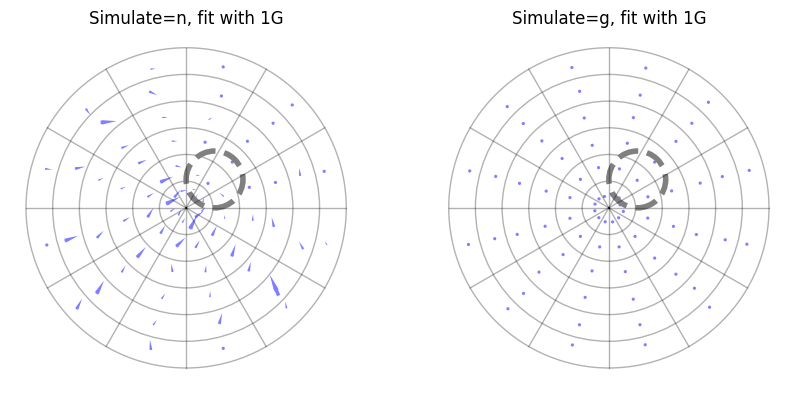

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans


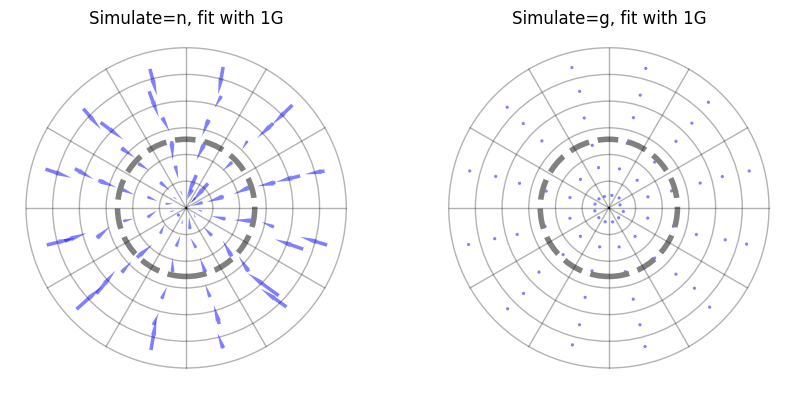

In [15]:
for t2 in ['AS1', 'AS2']:
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    for i,m in enumerate(['n','g']):
        rp_mask = pobj.return_vx_mask({
            f'{m}AS0-min-rsq':.1, 
            f'{m}AS0-max-ecc':5.0,
            f'{m}{t2}-min-rsq':.1, 
            f'{m}{t2}-max-ecc':5.0,
            })
        dXY = pobj.return_diff_params(f'{m}AS0', f'{m}{t2}', ['x', 'y'])
        dXY = {k: dXY[k][rp_mask].to_numpy() for k in dXY.keys()}
        shift = np.sqrt(dXY['x']**2 + dXY['y']**2)
        print(f'{m}, {t2}: m = {shift.mean():.3f}, std={shift.std():.3f}')
        pobj.arrow(f'{m}AS0', f'{m}{t2}', 
                th={
                    f'{m}AS0-min-rsq':.3,
                    f'{m}{t2}-min-rsq':.3,
                    f'{m}AS0-max-ecc':5.0 ,
                    f'{m}{t2}-max-ecc':5.0 
                    },
                do_binning=True, 
                ax=axs[i]
                )
        
        scot_patch = mpl.patches.Circle(
            scotoma_info[f'task-{t2}']['scotoma_centre'], 
            scotoma_info[f'task-{t2}']['scotoma_radius'], 
            color='grey', linewidth=4, 
            fill=False, alpha=1,
            linestyle='--', 
            label='Scotoma'
            )
        
        axs[i].add_patch(scot_patch)
        axs[i].set_title(f'Simulate={m}, fit with 1G')
    fig.savefig(opj(fig_output, f'sim_arrows{t2}.png'), bbox_inches='tight', dpi=150)
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

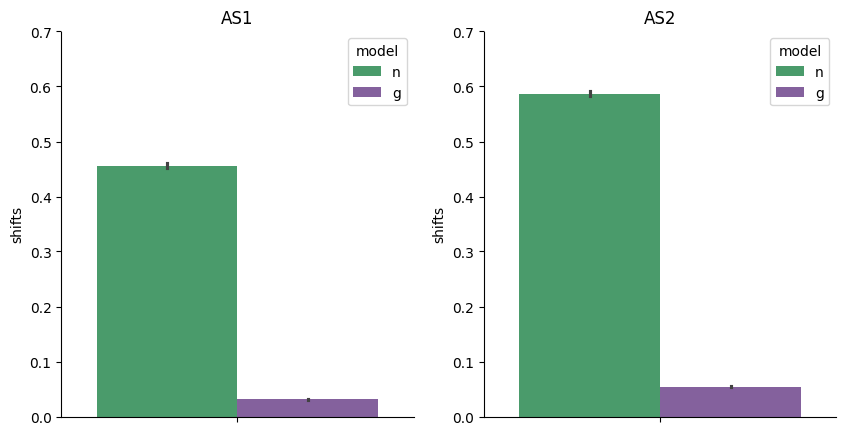

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

In [20]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
for iT,t2 in enumerate(['AS1', 'AS2']):
    shifts= {
        'model' : [],
        'shifts' : [],
    }
    for iM,m in enumerate(['n','g']):
        rp_mask = pobj.return_vx_mask({
            f'{m}AS0-min-rsq':.1, 
            f'{m}AS0-max-ecc':5.0,
            f'{m}{t2}-min-rsq':.1, 
            f'{m}{t2}-max-ecc':5.0,
            })
        dXY = pobj.return_diff_params(f'{m}AS0', f'{m}{t2}', ['x', 'y'])
        dXY = {k: dXY[k][rp_mask].to_numpy() for k in dXY.keys()}
        shift = np.sqrt(dXY['x']**2 + dXY['y']**2)
        shifts['shifts'].extend(shift)
        shifts['model'].extend([m]*shift.shape[0])
    
    tshift = pd.DataFrame(shifts)  
    plt.sca(axs[iT])
    sns.barplot(
        tshift, y='shifts', hue='model', errorbar='se', palette=[mod_cols['G'], mod_cols['N']]
    )
    sns.despine()
    axs[iT].set_ylim(0,0.7)
    axs[iT].set_title(t2)
plt.show()
fig.savefig(opj(fig_output, 'mean_shift_sim.png'), bbox_inches='tight', dpi=150)

## correlations

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

******* AS1 **********
    size_1    size_2     amp_1    amp_2     b_val     d_val  amp_ratio
0  0.23838  0.071991 -0.099147  0.07211 -0.023009 -0.001595   0.345371
******* AS2 **********
     size_1    size_2     amp_1     amp_2    b_val     d_val  amp_ratio
0  0.212688  0.054473 -0.092522  0.068423 -0.01254  0.000825   0.321178


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

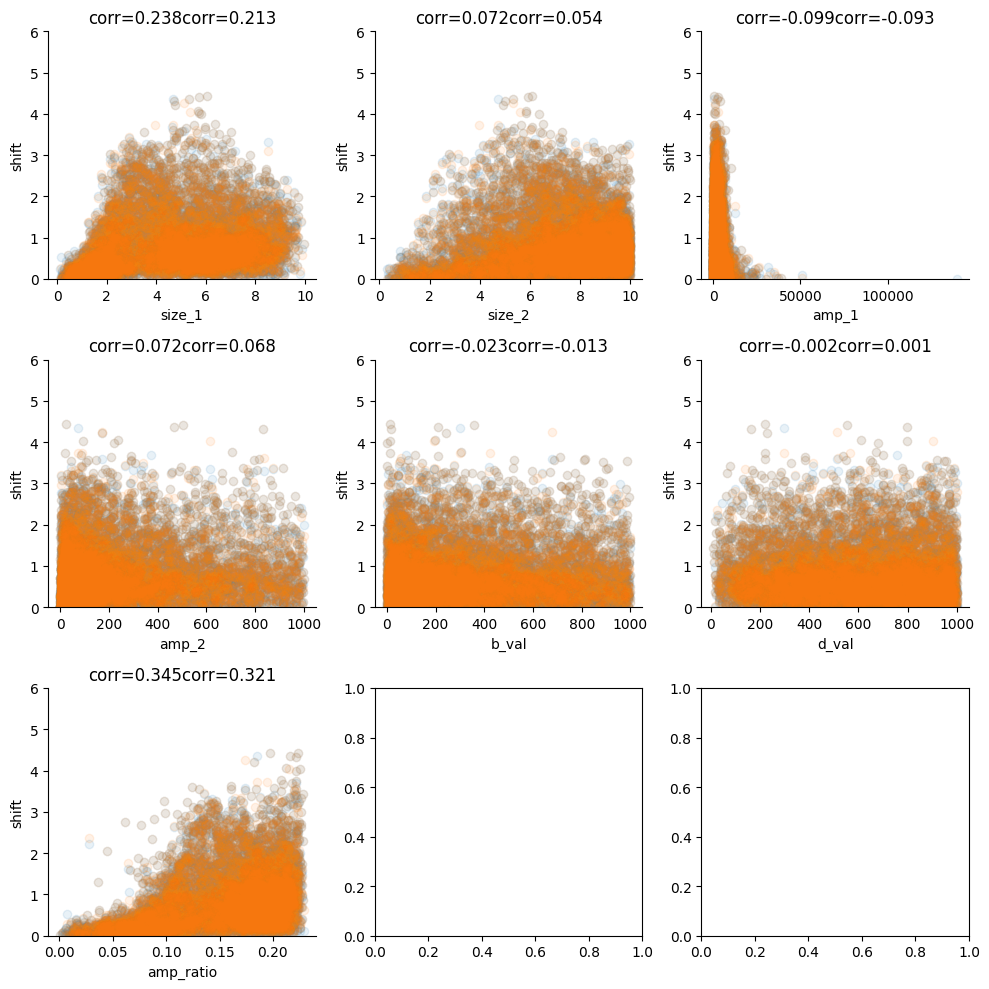

In [26]:
corr_id = ['size_1', 'size_2', 'amp_1', 'amp_2', 'b_val', 'd_val', 'amp_ratio',]

fig, axs = plt.subplots(3,3, figsize=(10,10))
axs = axs.flatten()

for iT,t2 in enumerate(['AS1', 'AS2']):
    tpars = {k:[] for k in corr_id}
    for iC,c in enumerate(corr_id): 
        rp_mask = pobj.return_vx_mask({
            f'nAS0-min-rsq':.1, 
            f'nAS0-max-ecc':5.0,
            f'n{t2}-min-rsq':.1, 
            f'n{t2}-max-ecc':5.0,
            })
        dXY = pobj.return_diff_params(f'nAS0', f'{m}{t2}', ['x', 'y'])
        dXY = {k: dXY[k][rp_mask].to_numpy() for k in dXY.keys()}
        shift = np.sqrt(dXY['x']**2 + dXY['y']**2)
        tcorr = dag_get_corr(
            shift, 
            pN.pd_params[c].iloc[rp_mask],
        )
        tpars[c].append(tcorr)
        dag_scatter(
            pN.pd_params[c].iloc[rp_mask],
            shift,   
            ax=axs[iC],
            do_corr=True, 
            dot_alpha=0.1, 
        )
        axs[iC].set_ylim(0,6)
        axs[iC].set_ylabel('shift')
        axs[iC].set_xlabel(c)

    tpd = pd.DataFrame(tpars)
    tpd.to_csv(f't2{t2}.csv')
    print(f'******* {t2} **********')
    print(tpd)
fig.set_tight_layout('tight')
%matplotlib inline


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

******* AS1 **********
     size_1    size_2     amp_1     amp_2     b_val    d_val  amp_ratio
0  0.009266  0.003895  0.010384  0.002146  0.000313 -0.01243  -0.005002
******* AS2 **********
     size_1    size_2     amp_1     amp_2   b_val     d_val  amp_ratio
0 -0.098913 -0.061113  0.012584 -0.020648  0.0005  0.013879  -0.046413


findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

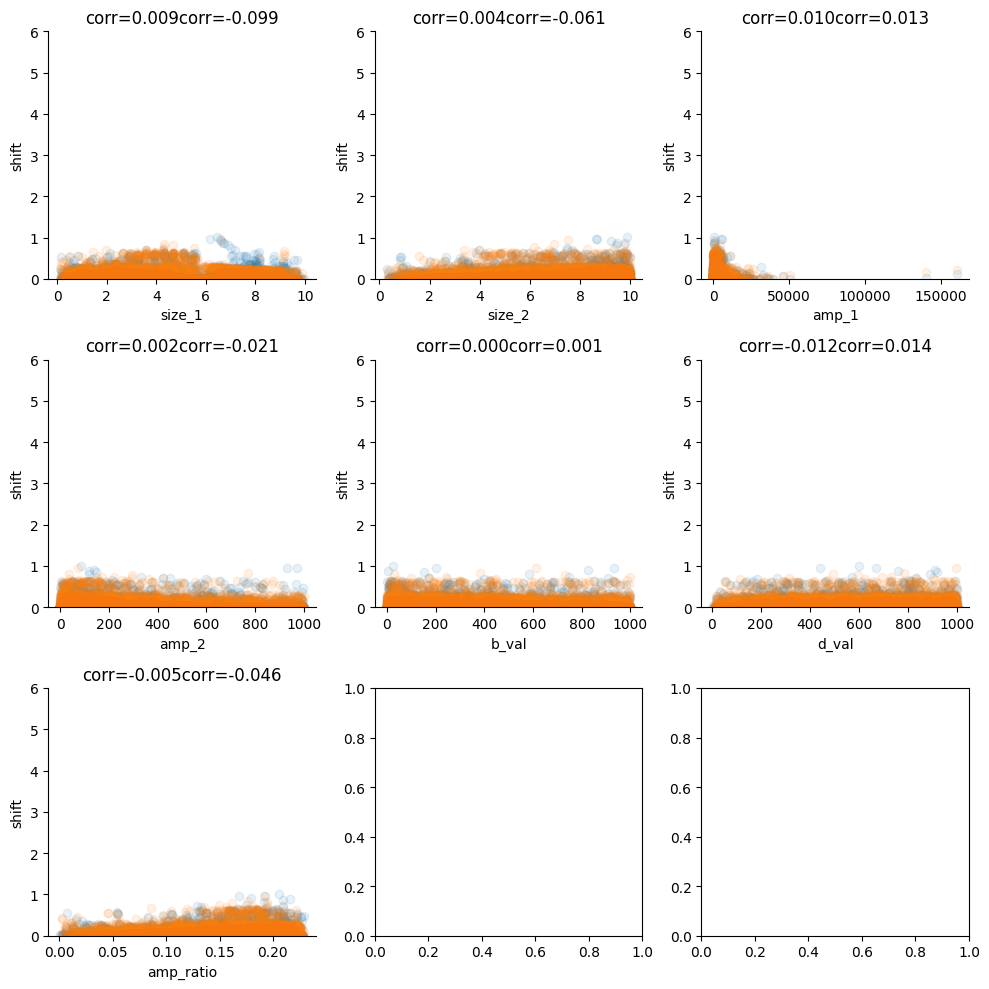

In [27]:
corr_id = ['size_1', 'size_2', 'amp_1', 'amp_2', 'b_val', 'd_val', 'amp_ratio',]

fig, axs = plt.subplots(3,3, figsize=(10,10))
axs = axs.flatten()

for iT,t2 in enumerate(['AS1', 'AS2']):
    tpars = {k:[] for k in corr_id}
    for iC,c in enumerate(corr_id): 
        rp_mask = pobj.return_vx_mask({
            f'gAS0-min-rsq':.1, 
            f'gAS0-max-ecc':5.0,
            f'g{t2}-min-rsq':.1, 
            f'g{t2}-max-ecc':5.0,
            })
        dXY = pobj.return_diff_params(f'gAS0', f'{m}{t2}', ['x', 'y'])
        dXY = {k: dXY[k][rp_mask].to_numpy() for k in dXY.keys()}
        shift = np.sqrt(dXY['x']**2 + dXY['y']**2)
        tcorr = dag_get_corr(
            shift, 
            pN.pd_params[c].iloc[rp_mask],
        )
        tpars[c].append(tcorr)
        dag_scatter(
            pN.pd_params[c].iloc[rp_mask],
            shift,   
            ax=axs[iC],
            do_corr=True, 
            dot_alpha=0.1, 
        )
        axs[iC].set_ylim(0,6)
        axs[iC].set_ylabel('shift')
        axs[iC].set_xlabel(c)

    tpd = pd.DataFrame(tpars)
    tpd.to_csv(f't2{t2}.csv')
    print(f'******* {t2} **********')
    print(tpd)
fig.set_tight_layout('tight')
%matplotlib inline
